# Exploratory Data Analysis



In [3]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [4]:
# loading datasets

df1 = pd.read_csv('data/UserData.csv')
df2 = pd.read_csv('data/Opportunity Wise Data.csv')


## 1. Explore the User Dataset
Objective: Get a comprehensive overview of the dataset to identify potential issues

In [6]:
df1.head()

,PreferredSponsors,Gender,Country,Degree,Sign Up Date,city,zip,isFromSocialMedia
0,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Male,Nigeria,Undergraduate Student,2023-07-23T08:05:58.602Z,Owerri,460103,False
1,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Male,India,Undergraduate Student,2023-04-24T09:57:07.405Z,kottayam,686501,False
2,"[""GlobalShala"",""Illinois Institute of Technolo...",NaN,India,NaN,2022-10-14T17:13:36.303Z,NaN,NaN,False
3,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",NaN,Albania,NaN,2023-06-06T12:29:01.772Z,NaN,NaN,True
4,"[""GlobalShala"",""Grant Thornton China"",""Saint L...",Female,Ghana,Not in Education,2023-06-15T16:31:42.719Z,Kumasi,AT-1214-9090,False


In [7]:
df1.shape

(27562, 8)

In [8]:
# Explore dataset structure
print("Dataset Info:")
print(df1.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27562 entries, 0 to 27561
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   PreferredSponsors  27562 non-null  object
 1   Gender             18027 non-null  object
 2   Country            27500 non-null  object
 3   Degree             16750 non-null  object
 4   Sign Up Date       27562 non-null  object
 5   city               18028 non-null  object
 6   zip                18018 non-null  object
 7   isFromSocialMedia  27553 non-null  object
dtypes: object(8)
memory usage: 1.7+ MB
None


In [9]:
# Display summary statistics
print("\nSummary Statistics:")
print(df1.describe(include='all'))


Summary Statistics:
                                        PreferredSponsors Gender Country  \
count                                               27562  18027   27500   
unique                                                 94      4     169   
top     ["GlobalShala","Grant Thornton China","Saint L...   Male   India   
freq                                                22011  11027   11893   

                       Degree              Sign Up Date       city    zip  \
count                   16750                     27562      18028  18018   
unique                      4                     27561       4727   7453   
top     Undergraduate Student  2022-10-30T17:25:54.072Z  Hyderabad  63108   
freq                     6527                         2        743    629   

       isFromSocialMedia  
count              27553  
unique                 2  
top                 True  
freq               13811  


In [10]:
# Check unique values in each column
for column in df1.columns:
        print(f"{column}: {df1[column].nunique()} unique values")

PreferredSponsors: 94 unique values
Gender: 4 unique values
Country: 169 unique values
Degree: 4 unique values
Sign Up Date: 27561 unique values
city: 4727 unique values
zip: 7453 unique values
isFromSocialMedia: 2 unique values


In [11]:
memory_usage = df1.memory_usage(deep=True)
print(memory_usage)

Index                    132
PreferredSponsors    4247101
Gender               1275661
Country              1546625
Degree               1520175
Sign Up Date         2012026
city                 1326919
zip                  1286877
isFromSocialMedia     992196
dtype: int64


## 1.1 Explore the Opportunity Wise Dataset
Objective: Get a comprehensive overview of the dataset to identify potential issues


In [13]:
df2.head()

,Profile Id,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,Gender,City,State,Country,Zip Code,...,Current Student Status,Current/Intended Major,Status Description,Apply Date,Opportunity Start Date,Reward Amount,Badge Id,Badge Name,Skill Points Earned,Skills Earned
0,31ce84c2-2bd1-40ba-b2d8-f164fe125306,00000000-0G4F-19XB-EXPW-KS8F3N,Statement of Purpose (SOP) Writing Workshop,Event,"Jan 05, 2023, 18:58:39",Male,Dhaka,Savar,Bangladesh,1342,...,High School Student,Data Science,Not Started,"Oct 03, 2022, 17:29:17","Jan 05, 2023, 18:52:39",NaN,NaN,NaN,NaN,NaN
1,36814990-f854-4f76-8c63-91f27567d080,00000000-0G4F-19XB-EXPW-KS8F3N,Statement of Purpose (SOP) Writing Workshop,Event,"Jan 05, 2023, 18:58:39",Female,Amritsar,Punjab,Afghanistan,123242,...,Undergraduate Student,Otheraassss,Rewards Award,"Jan 05, 2023, 18:58:37","Jan 05, 2023, 18:52:39",200.0,00000000-0GSP-A3RB-BT5G-1ECTG9,Statement of Purpose (SOP) Writing Workshop,10.0,"[""Critical Thinking"",""Creative Thinking"",""Comm..."
2,8154328c-f8fe-4bd1-af05-783e140f68b5,00000000-0G4F-19XB-EXPW-KS8F3N,Statement of Purpose (SOP) Writing Workshop,Event,"Jan 05, 2023, 18:58:39",Female,Satna,Madhya pradesh,India,485001,...,High School Student,Computer Science and Engineering,Not Started,"Oct 04, 2022, 8:10:07","Jan 05, 2023, 18:52:39",NaN,NaN,NaN,NaN,NaN
3,a83abad6-db1e-44c4-a8f4-9e397e282d73,00000000-0G4F-19XB-EXPW-KS8F3N,Statement of Purpose (SOP) Writing Workshop,Event,"Jan 05, 2023, 18:58:39",Male,Hyderabad,Telangana,India,500039,...,Graduate Program Student,Computer Science,Not Started,"Oct 05, 2022, 13:41:47","Jan 05, 2023, 18:52:39",NaN,NaN,NaN,NaN,NaN
4,c2b8a15f-2ba3-41e4-a553-7ca68b0d4a54,00000000-0G4F-19XB-EXPW-KS8F3N,Statement of Purpose (SOP) Writing Workshop,Event,"Jan 05, 2023, 18:58:39",Male,Bangalore,Karnataka,India,560105,...,Undergraduate Student,jknhk,Not Started,"Oct 05, 2022, 11:07:17","Jan 05, 2023, 18:52:39",NaN,NaN,NaN,NaN,NaN


In [14]:
df2.shape

(20322, 21)

In [15]:
# Explore dataset structure
print("Dataset Info:")
print(df2.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20322 entries, 0 to 20321
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Profile Id                20322 non-null  object 
 1   Opportunity Id            20322 non-null  object 
 2   Opportunity Name          20322 non-null  object 
 3   Opportunity Category      20322 non-null  object 
 4   Opportunity End Date      20322 non-null  object 
 5   Gender                    20321 non-null  object 
 6   City                      20321 non-null  object 
 7   State                     20308 non-null  object 
 8   Country                   20322 non-null  object 
 9   Zip Code                  20309 non-null  object 
 10  Graduation Date(YYYY MM)  20321 non-null  object 
 11  Current Student Status    20321 non-null  object 
 12  Current/Intended Major    20278 non-null  object 
 13  Status Description        20322 non-null  objec

In [16]:
# Display summary statistics
print("\nSummary Statistics:")
print(df2.describe(include='all'))


Summary Statistics:
                                  Profile Id                  Opportunity Id  \
count                                  20322                           20322   
unique                                 11481                              33   
top     18e1e6bc-fada-4b09-bf52-ab45daf318f4  00000000-0GWQ-AXC5-X45C-2MHJ28   
freq                                      22                            5687   
mean                                     NaN                             NaN   
std                                      NaN                             NaN   
min                                      NaN                             NaN   
25%                                      NaN                             NaN   
50%                                      NaN                             NaN   
75%                                      NaN                             NaN   
max                                      NaN                             NaN   

          Opportun

## 2. Handle Missing Values
Objective: Address missing values to prevent bias and improve analysis accuracy.

### 2.2. Using missingno to visualize missing data


 Visualizing missing values for User Dataset


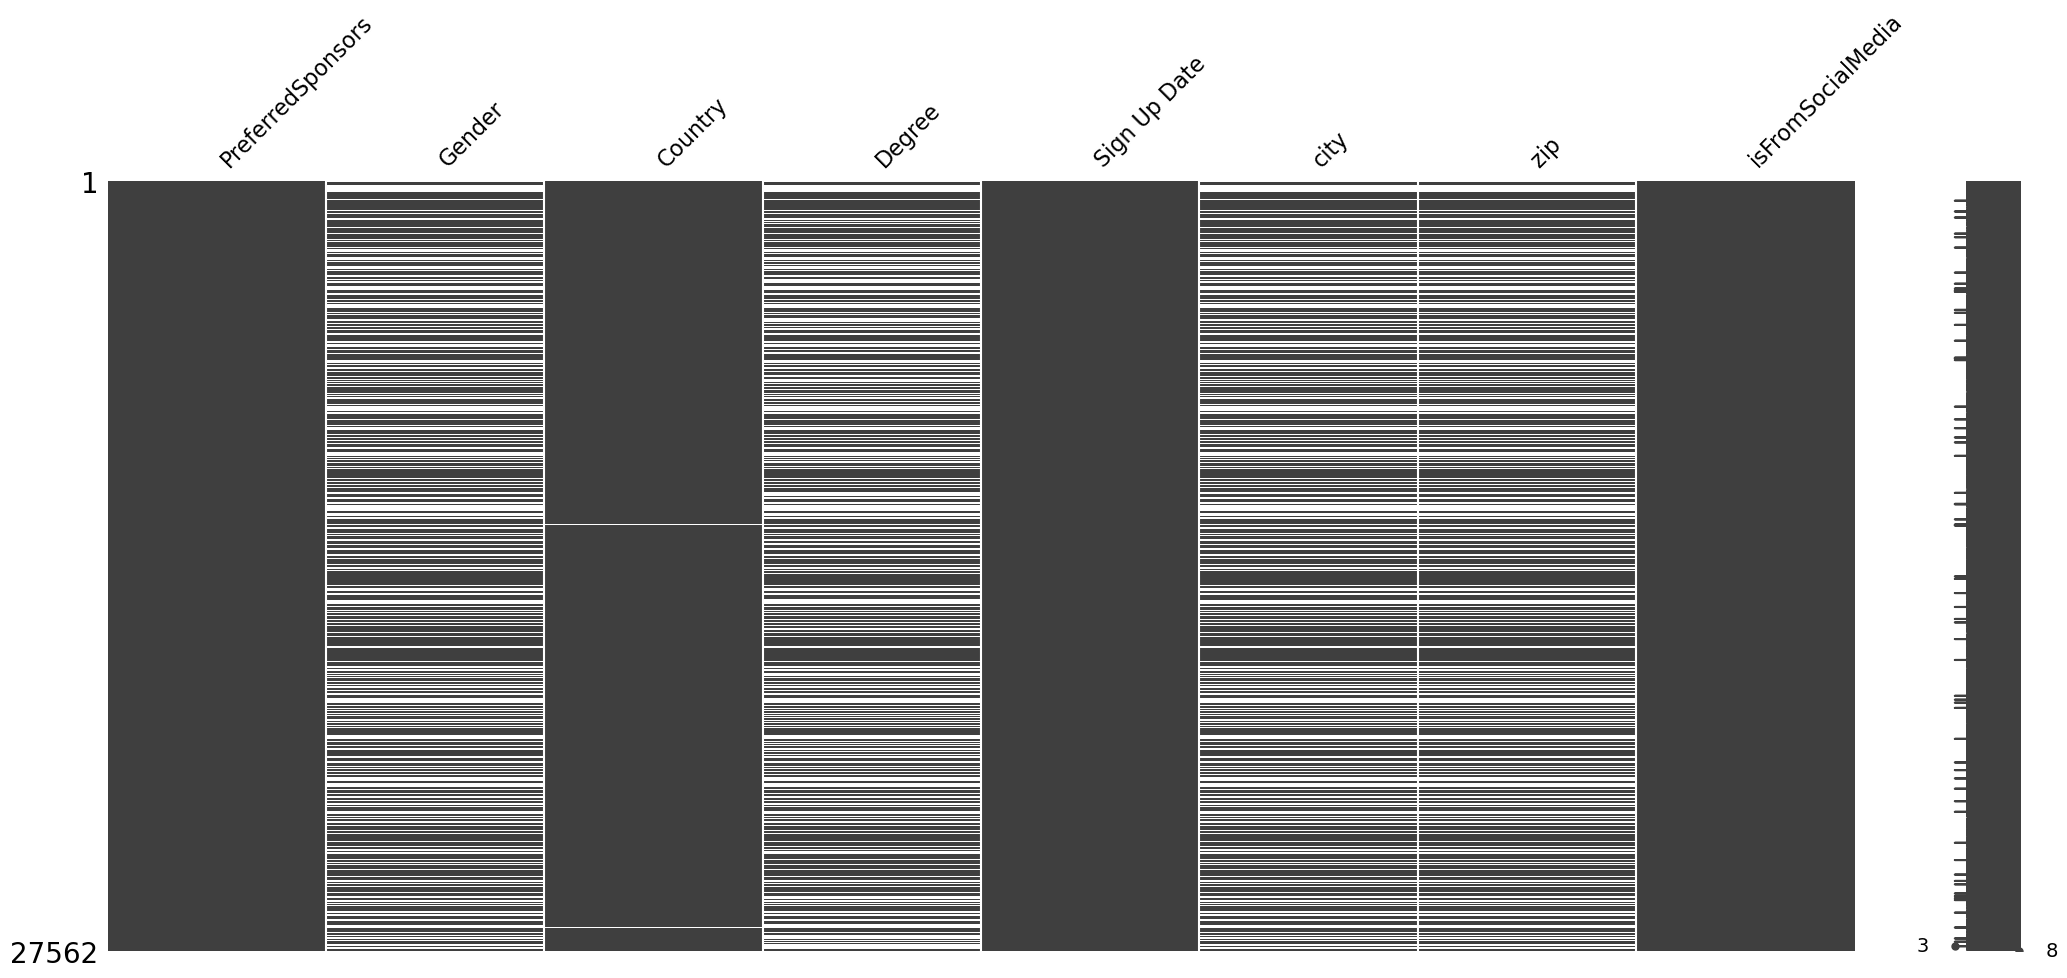

In [19]:
# Visualize distributions
msno.matrix(df1)
print('\n Visualizing missing values for User Dataset')


 Visualizing missing values for User Dataset


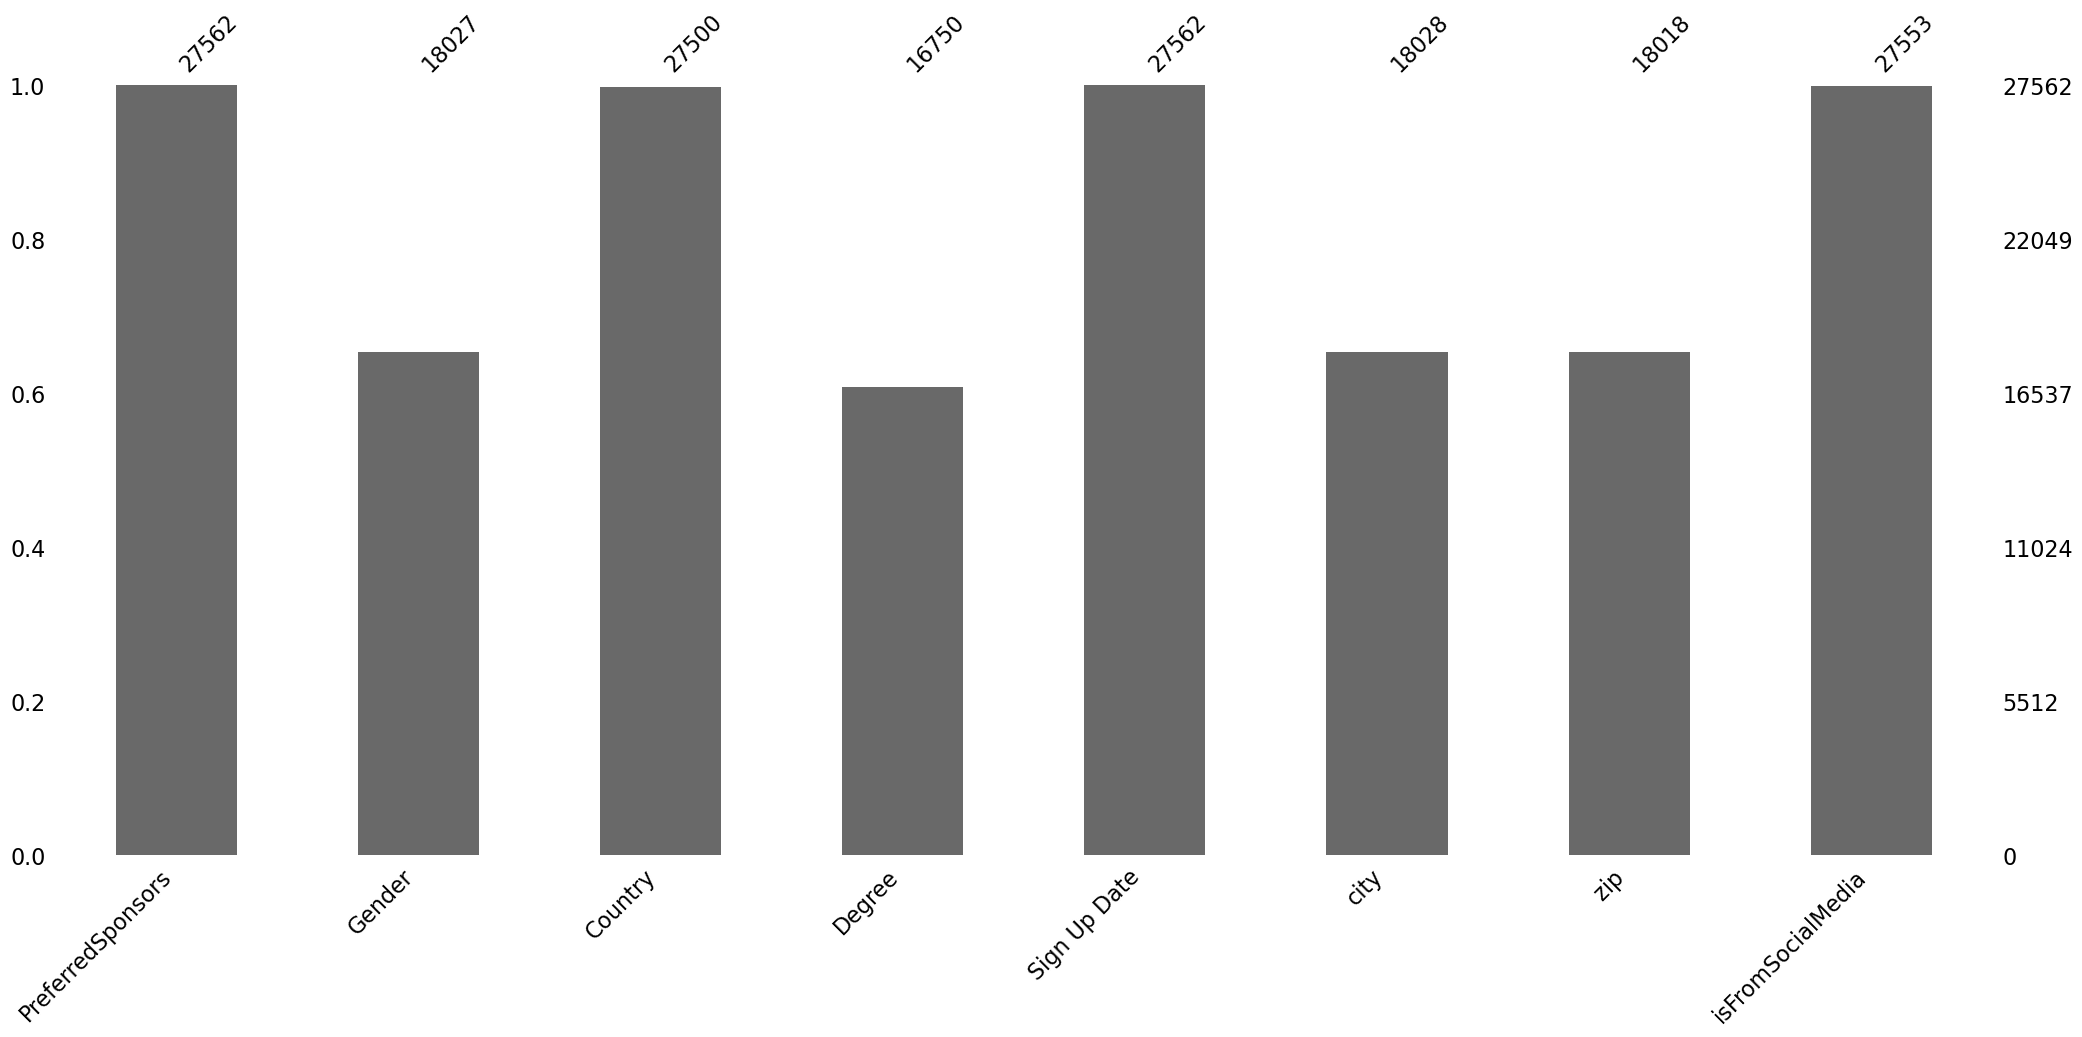

In [21]:
msno.bar(df1)
print('\n Visualizing missing values for User Dataset')



 Visualizing missing values for User Dataset


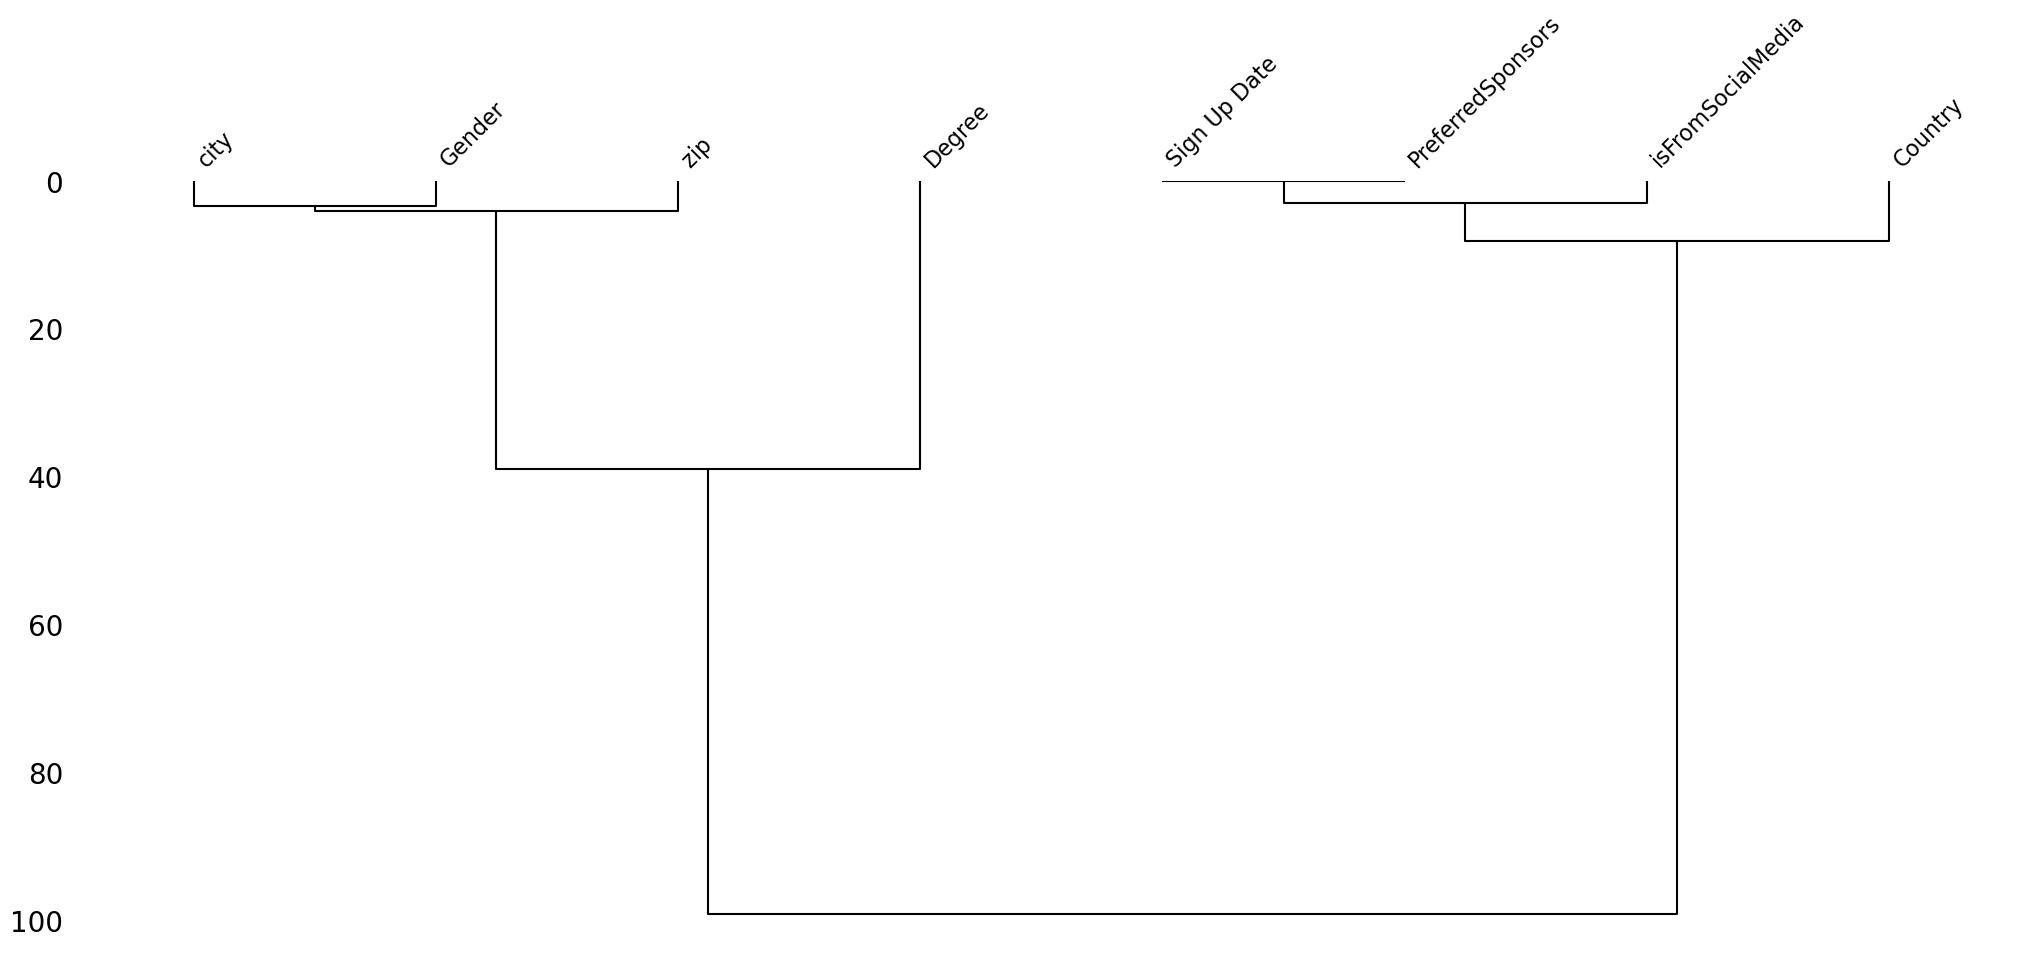

In [23]:
msno.dendrogram(df1)
print('\n Visualizing missing values for User Dataset')

### 2.3. Identify missing values

In [26]:
missing_values_1 = df1.isnull().sum()
print("Missing Values for User Data:\n", missing_values_1)

Missing Values for User Data:
 PreferredSponsors        0
Gender                9535
Country                 62
Degree               10812
Sign Up Date             0
city                  9534
zip                   9544
isFromSocialMedia        9
dtype: int64


we can see that only sign up date and preferred sponsers has no missing values, but rest of the value is missing

In [36]:
missing_values_2 = df2.isnull().sum()
print("Missing Values for User Data for Opportunity Wise Dataset:\n", missing_values_2)

Missing Values for User Data for Opportunity Wise Dataset:
 Profile Id                      0
Opportunity Id                  0
Opportunity Name                0
Opportunity Category            0
Opportunity End Date            0
Gender                          1
City                            1
State                          14
Country                         0
Zip Code                       13
Graduation Date(YYYY MM)        1
Current Student Status          1
Current/Intended Major         44
Status Description              0
Apply Date                      0
Opportunity Start Date        804
Reward Amount               17801
Badge Id                    17801
Badge Name                  17801
Skill Points Earned         17801
Skills Earned               17801
dtype: int64


we can see that only sign up date and preferred sponsers has no missing values, but rest of the value is missing

In [ ]:
# Check the percentage of missing values in each column
missing_percentage = df1.isnull().mean() * 100
print('Total missing Percentage: \n\n', missing_percentage)

# Visualize missing data for User Data
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df1.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()


In [ ]:
# Check the percentage of missing values in each column
missing_percentage = df1.isnull().mean() * 100
print('Total missing Percentage: \n\n',missing_percentage)

# Visualize missing Opportunity Wise Dataset
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df2.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

### Categorize Columns by Missing Percentage
Low Missingness (< 5%): Impute or remove the missing values.

Moderate Missingness (5%-30%): Impute with statistical methods or domain knowledge.

High Missingness (> 30%): Decide based on importance—drop the column or impute creatively.

# whats next

In [38]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27562 entries, 0 to 27561
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   PreferredSponsors  27562 non-null  object
 1   Gender             18027 non-null  object
 2   Country            27500 non-null  object
 3   Degree             16750 non-null  object
 4   Sign Up Date       27562 non-null  object
 5   city               18028 non-null  object
 6   zip                18018 non-null  object
 7   isFromSocialMedia  27553 non-null  object
dtypes: object(8)
memory usage: 1.7+ MB


# Step 1: Check for Missing Values

In [40]:
import pandas as pd

# Check missing values
print(df1.isnull().sum())

# Check percentage of missing values
missing_percent = df1.isnull().sum() / len(df1) * 100
print(missing_percent)


PreferredSponsors        0
Gender                9535
Country                 62
Degree               10812
Sign Up Date             0
city                  9534
zip                   9544
isFromSocialMedia        9
dtype: int64
PreferredSponsors     0.000000
Gender               34.594732
Country               0.224947
Degree               39.227923
Sign Up Date          0.000000
city                 34.591104
zip                  34.627386
isFromSocialMedia     0.032654
dtype: float64


# Step 2: Handling Missing Values

1. Drop Columns wi`th Too Many Missing Values
If a column has too many missing values (e.g., >40%), consider dropping it.

In [42]:
df1.drop(columns=['zip'], inplace=True)  # Dropping 'zip' if 'city' already provides location info


In [59]:
# Check the distribution of 'Degree' before imputation
degree_distribution = df1['Degree'].value_counts()
print(degree_distribution)

# Impute missing 'Degree' with the most frequent value (mode)
df1['Degree'].fillna(df1['Degree'].mode()[0], inplace=True)

# Verify if missing values in 'Degree' have been handled
print(df1['Degree'].isnull().sum())

# Check the distribution of 'Degree' after imputation
degree_distribution_after = df1['Degree'].value_counts()
print(degree_distribution_after)

Degree
Undergraduate Student       17339
Graduate Program Student     6015
Not in Education             2646
High School Student          1562
Name: count, dtype: int64
0
Degree
Undergraduate Student       17339
Graduate Program Student     6015
Not in Education             2646
High School Student          1562
Name: count, dtype: int64


In [63]:
# Check the distribution of 'City' before imputation
city_distribution = df1['city'].value_counts()
print(city_distribution)

# Impute missing 'City' with the most frequent value (mode)
df1['city'].fillna(df1['city'].mode()[0], inplace=True)

# Verify if missing values in 'City' have been handled
print(df1['city'].isnull().sum())

# Check the distribution of 'City' after imputation
city_distribution_after = df1['city'].value_counts()
print(city_distribution_after)


city
Hyderabad        743
Saint Louis      469
Lagos            450
Accra            336
Chicago          318
                ... 
Joahnnesburg       1
locust             1
Guj                1
absecon            1
Daraban kalan      1
Name: count, Length: 4727, dtype: int64
0
city
Hyderabad        10277
Saint Louis        469
Lagos              450
Accra              336
Chicago            318
                 ...  
Joahnnesburg         1
locust               1
Guj                  1
absecon              1
Daraban kalan        1
Name: count, Length: 4727, dtype: int64


In [69]:
# Check the distribution of 'Gender' before imputation
gender_distribution = df1['Gender'].value_counts()
print(gender_distribution)


# Define the proportions based on the gender distribution
gender_proportions = {
    'Male': 11027 / (11027 + 6910 + 75 + 15),
    'Female': 6910 / (11027 + 6910 + 75 + 15),
    "Don't want to specify": 75 / (11027 + 6910 + 75 + 15),
    'Other': 15 / (11027 + 6910 + 75 + 15)
}

# Generate a list of possible gender values based on the proportions
gender_values = list(gender_proportions.keys())
gender_weights = list(gender_proportions.values())

# Randomly impute missing gender values based on the proportions
missing_gender_count = df1['Gender'].isnull().sum()
imputed_genders = np.random.choice(gender_values, size=missing_gender_count, p=gender_weights)

# Fill missing values with the imputed genders
df1.loc[df1['Gender'].isnull(), 'Gender'] = imputed_genders

# Verify if missing values in 'Gender' have been handled
print(df1['Gender'].isnull().sum())


Gender
Male                     11027
Female                    6910
Don't want to specify       75
Other                       15
Name: count, dtype: int64
0


In [75]:
import pandas as pd

# Check missing values
print(df1.isnull().sum())

# Check percentage of missing values
missing_percent = df1.isnull().sum() / len(df1) * 100
print(missing_percent)


PreferredSponsors    0
Gender               0
Country              0
Degree               0
Sign Up Date         0
city                 0
isFromSocialMedia    0
dtype: int64
PreferredSponsors    0.0
Gender               0.0
Country              0.0
Degree               0.0
Sign Up Date         0.0
city                 0.0
isFromSocialMedia    0.0
dtype: float64


In [73]:
# Impute missing 'Country' with the most frequent value (mode)
df1['Country'].fillna(df1['Country'].mode()[0], inplace=True)

# Impute missing 'isFromSocialMedia' with the most frequent value (mode)
df1['isFromSocialMedia'].fillna(df1['isFromSocialMedia'].mode()[0], inplace=True)



 Visualizing missing values for User Dataset


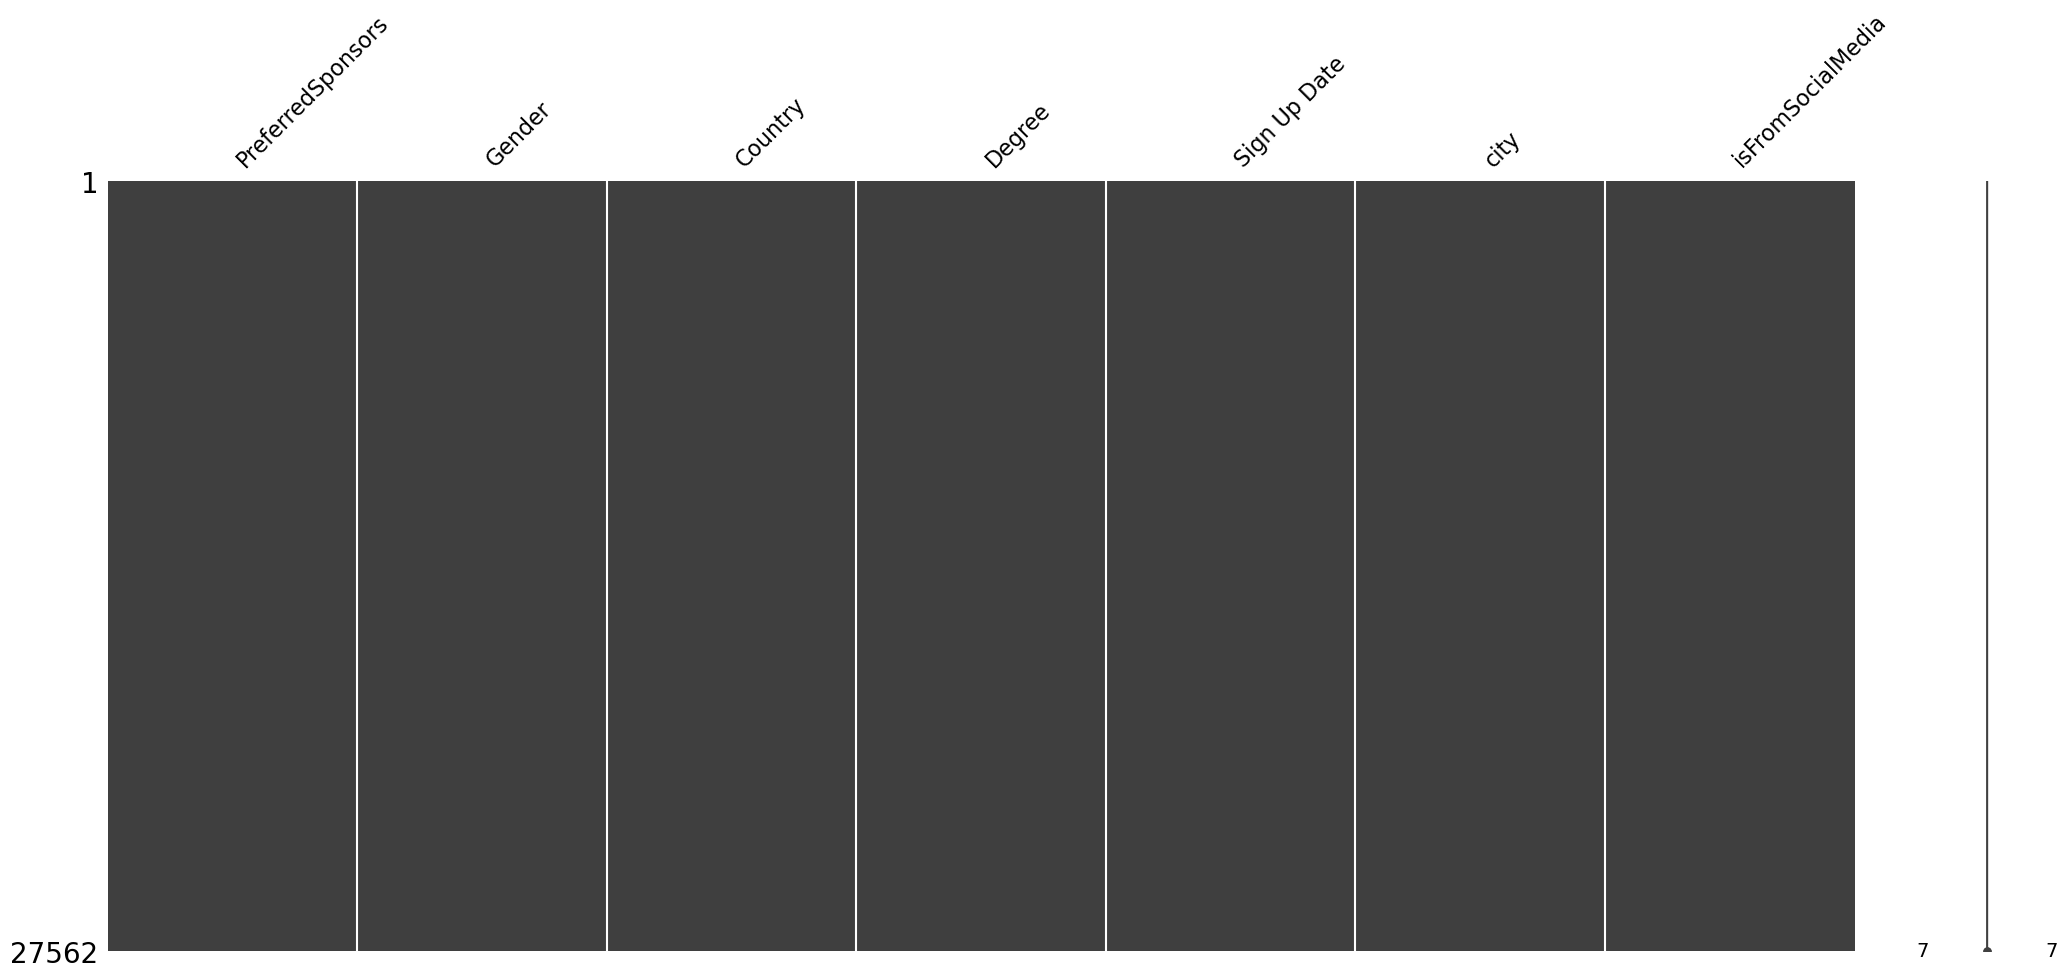

In [77]:
# Visualize distributions
msno.matrix(df1)
print('\n Visualizing missing values for User Dataset')


 Visualizing missing values for User Dataset


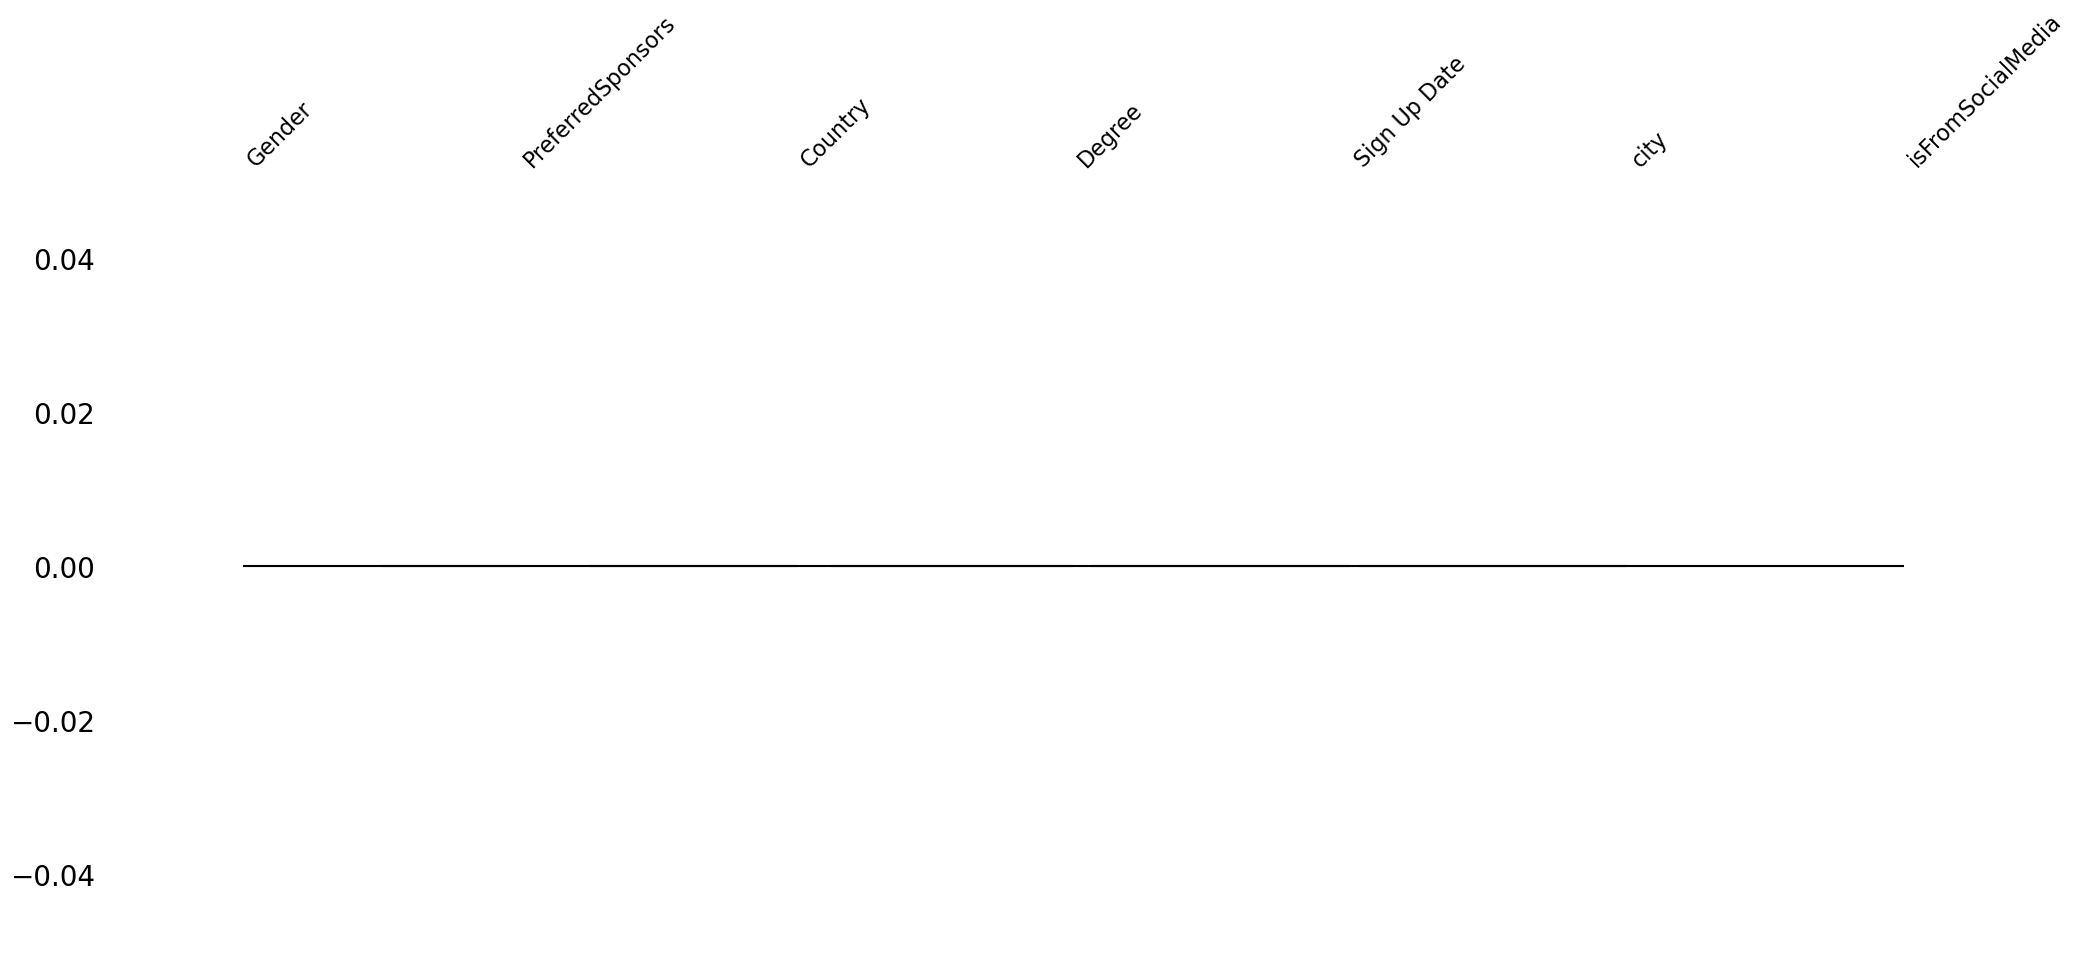

In [79]:
msno.dendrogram(df1)
print('\n Visualizing missing values for User Dataset')

In [85]:
# Export the cleaned DataFrame to a CSV file
df1.to_csv('data/UserData_cleaned.csv', index=False)


 Visualizing missing values for Opportunity Wise Dataset


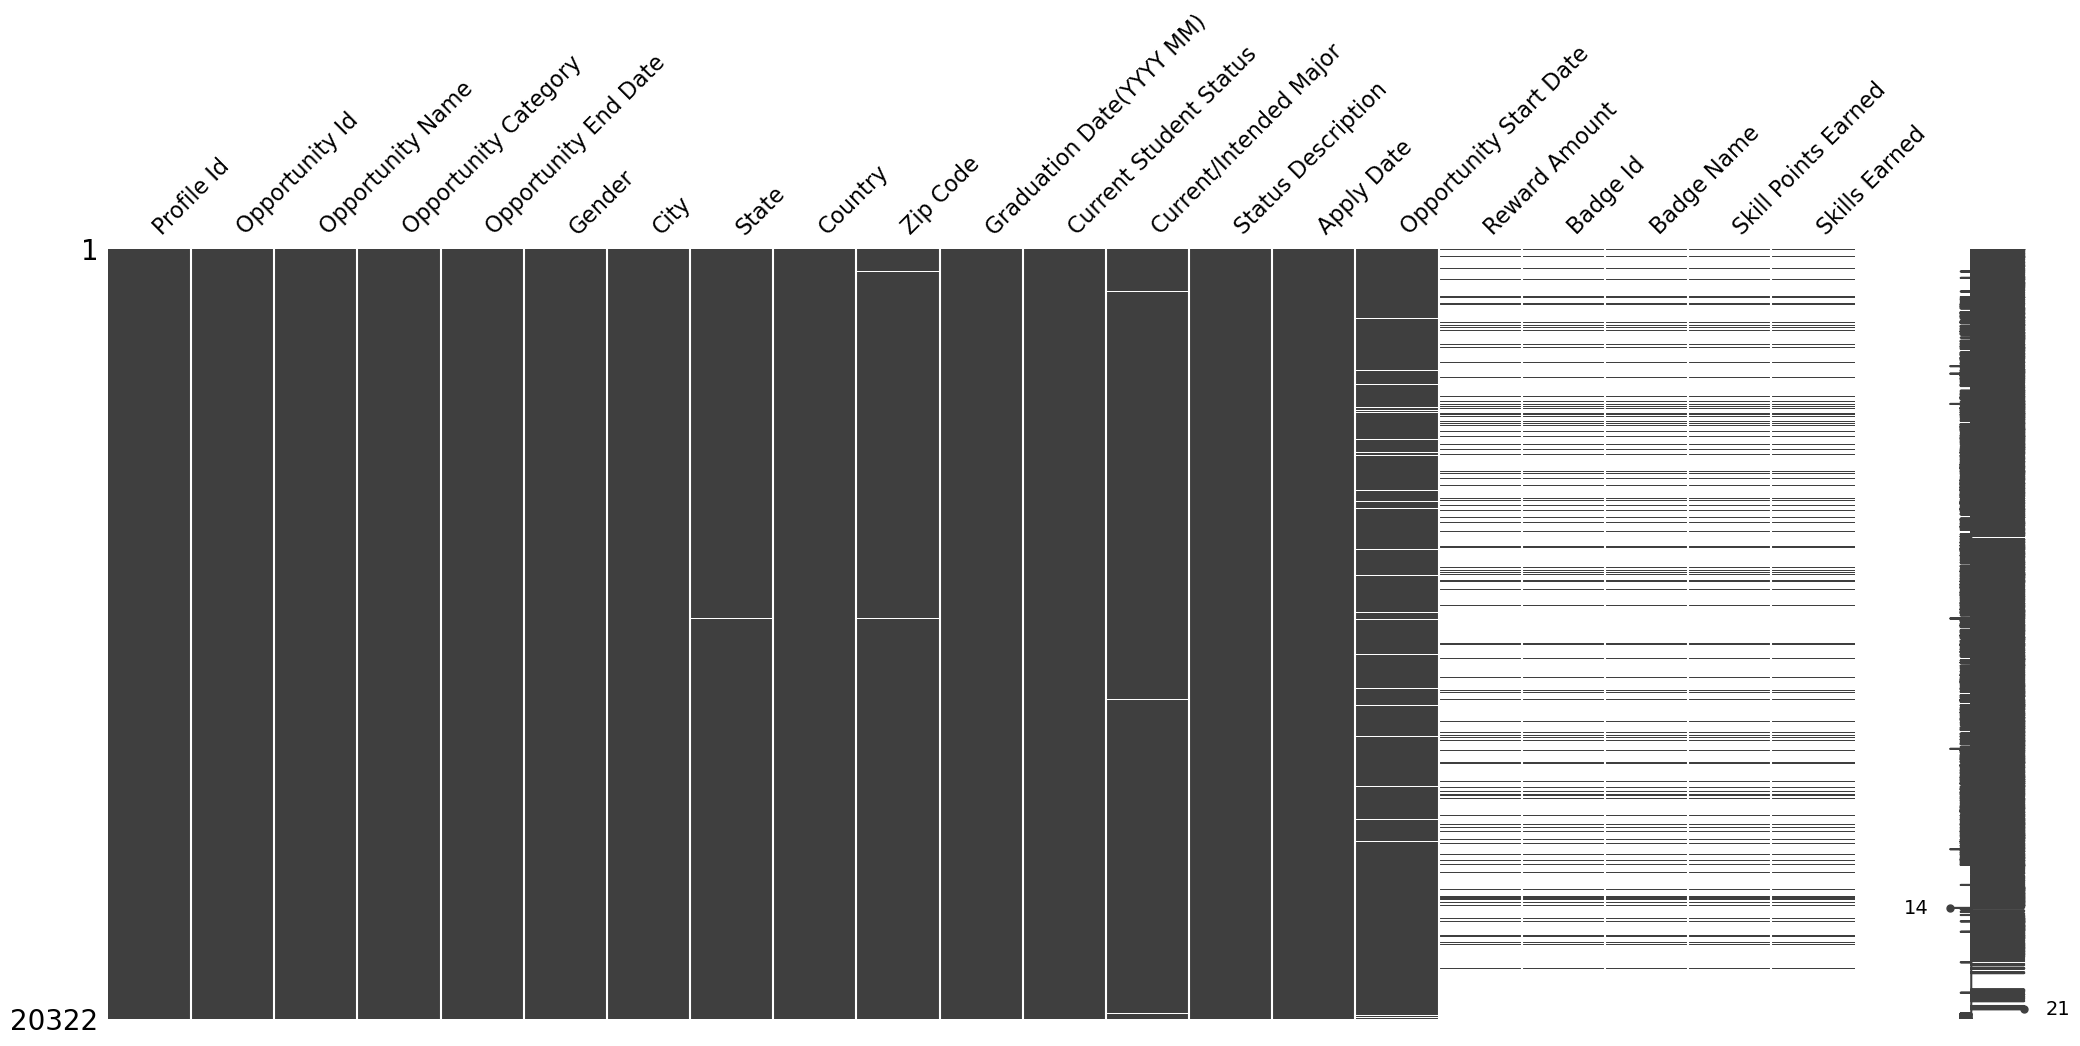

In [87]:
msno.matrix(df2)
print('\n Visualizing missing values for Opportunity Wise Dataset')


 Visualizing missing values for Opportunity Wise Dataset


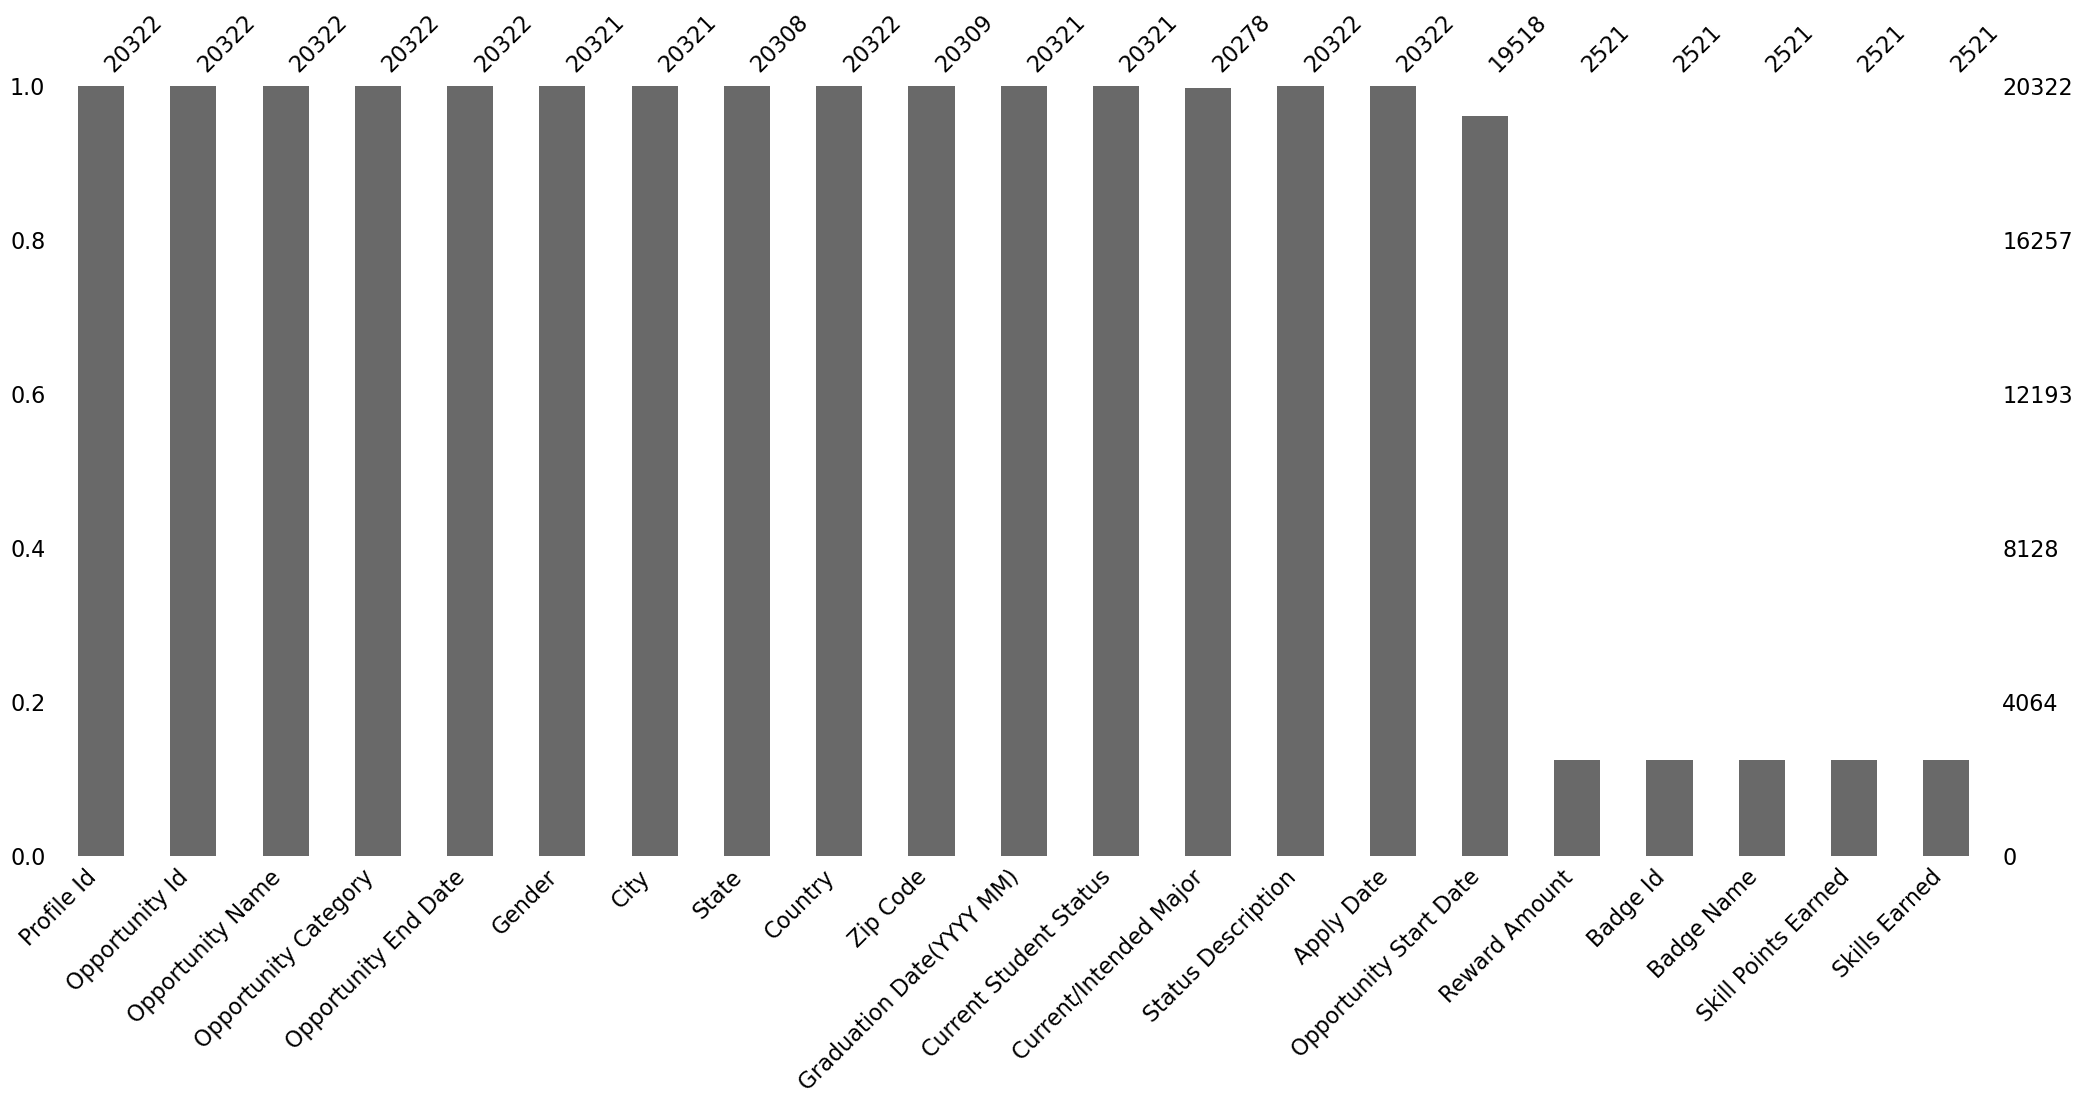

In [89]:
msno.bar(df2)
print('\n Visualizing missing values for Opportunity Wise Dataset')


 Visualizing missing values for Opportunity Wise Dataset


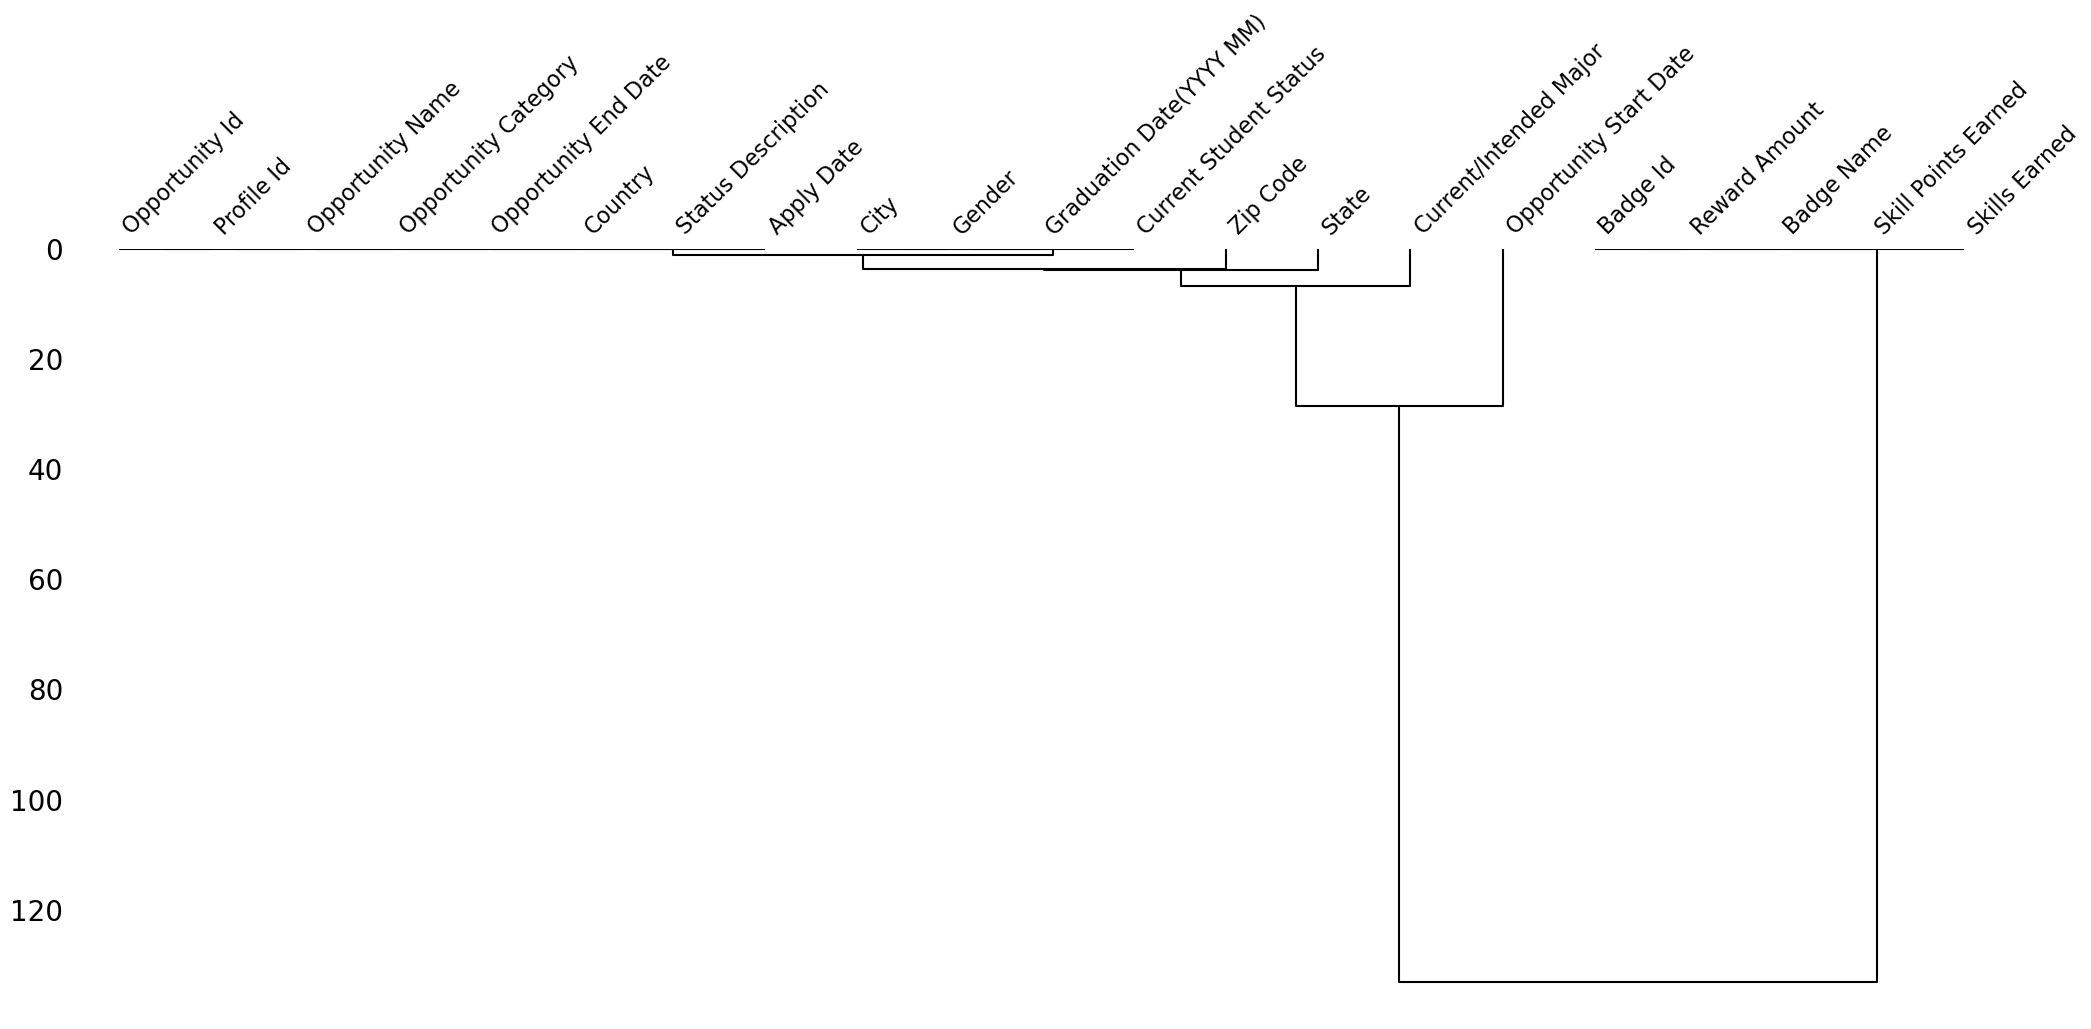

In [91]:
msno.dendrogram(df2)
print('\n Visualizing missing values for Opportunity Wise Dataset')

# The closer the branching is to zero, the higher the correlation is of missing numbers; 

In [93]:
# Get basic information about the dataset
df2_info = df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20322 entries, 0 to 20321
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Profile Id                20322 non-null  object 
 1   Opportunity Id            20322 non-null  object 
 2   Opportunity Name          20322 non-null  object 
 3   Opportunity Category      20322 non-null  object 
 4   Opportunity End Date      20322 non-null  object 
 5   Gender                    20321 non-null  object 
 6   City                      20321 non-null  object 
 7   State                     20308 non-null  object 
 8   Country                   20322 non-null  object 
 9   Zip Code                  20309 non-null  object 
 10  Graduation Date(YYYY MM)  20321 non-null  object 
 11  Current Student Status    20321 non-null  object 
 12  Current/Intended Major    20278 non-null  object 
 13  Status Description        20322 non-null  object 
 14  Apply 

In [113]:

# Get a summary of descriptive statistics
df2_description = df2.describe(include='all')
print(df2_description)

                                  Profile Id                  Opportunity Id  \
count                                  20322                           20322   
unique                                 11481                              33   
top     18e1e6bc-fada-4b09-bf52-ab45daf318f4  00000000-0GWQ-AXC5-X45C-2MHJ28   
freq                                      22                            5687   
mean                                     NaN                             NaN   
std                                      NaN                             NaN   
min                                      NaN                             NaN   
25%                                      NaN                             NaN   
50%                                      NaN                             NaN   
75%                                      NaN                             NaN   
max                                      NaN                             NaN   

          Opportunity Name Opportunity 

In [101]:
# Remove rows where Reward Amount, Badge Id, Badge Name, Skill Points Earned, or Skills Earned are missing
df2_cleaned = df2.dropna(subset=['Reward Amount', 'Badge Id', 'Badge Name', 'Skill Points Earned', 'Skills Earned'])


In [105]:

# Drop 'Zip Code' if not relevant to the business question
df2_cleaned = df2.drop(columns=['Zip Code'])

In [116]:
import pandas as pd

# Check missing values
print(df2.isnull().sum())

# Check percentage of missing values
missing_percent = df2.isnull().sum() / len(df1) * 100
print(missing_percent)


Profile Id                      0
Opportunity Id                  0
Opportunity Name                0
Opportunity Category            0
Opportunity End Date            0
Gender                          1
City                            1
State                          14
Country                         0
Zip Code                       13
Graduation Date(YYYY MM)        1
Current Student Status          1
Current/Intended Major         44
Status Description              0
Apply Date                      0
Opportunity Start Date        804
Reward Amount               17801
Badge Id                    17801
Badge Name                  17801
Skill Points Earned         17801
Skills Earned               17801
dtype: int64
Profile Id                   0.000000
Opportunity Id               0.000000
Opportunity Name             0.000000
Opportunity Category         0.000000
Opportunity End Date         0.000000
Gender                       0.003628
City                         0.003628
State  

In [118]:
# Impute missing columns with median or flag missing for business questions
df2['Reward Amount'] = df2['Reward Amount'].fillna(df2['Reward Amount'].median())
df2['Badge Id'] = df2['Badge Id'].fillna(df2['Badge Id'].mode()[0])  # Most frequent value
df2['Badge Name'] = df2['Badge Name'].fillna(df2['Badge Name'].mode()[0])  # Most frequent value
df2['Skill Points Earned'] = df2['Skill Points Earned'].fillna(df2['Skill Points Earned'].median())
df2['Skills Earned'] = df2['Skills Earned'].fillna(df2['Skills Earned'].mode()[0])


In [120]:
# Remove rows with missing Opportunity Start Date, or impute if needed
df2 = df2.dropna(subset=['Opportunity Start Date'])


In [122]:
# Impute or drop rows with missing State values
df2['State'] = df2['State'].fillna(df2['State'].mode()[0])  # Impute with most frequent state


In [124]:
# Drop Zip Code if irrelevant to business or impute if necessary
df2 = df2.drop(columns=['Zip Code'], errors='ignore')


In [126]:
# Impute Graduation Date if missing
df2['Graduation Date(YYYY MM)'] = df2['Graduation Date(YYYY MM)'].fillna('Unknown')


In [128]:
# Impute Current Student Status
df2['Current Student Status'] = df2['Current Student Status'].fillna('Unknown')


In [130]:
# Impute or flag missing Current/Intended Major
df2['Current/Intended Major'] = df2['Current/Intended Major'].fillna('Unknown')


In [132]:
# Impute missing Gender based on mode (most frequent value)
df2['Gender'] = df2['Gender'].fillna(df2['Gender'].mode()[0])


In [134]:
# Impute missing City with the most frequent city
df2['City'] = df2['City'].fillna(df2['City'].mode()[0])


In [136]:
# Drop duplicates if any
df2 = df2.drop_duplicates()


In [138]:
import pandas as pd

# Check missing values
print(df2.isnull().sum())

# Check percentage of missing values
missing_percent = df2.isnull().sum() / len(df1) * 100
print(missing_percent)


Profile Id                  0
Opportunity Id              0
Opportunity Name            0
Opportunity Category        0
Opportunity End Date        0
Gender                      0
City                        0
State                       0
Country                     0
Graduation Date(YYYY MM)    0
Current Student Status      0
Current/Intended Major      0
Status Description          0
Apply Date                  0
Opportunity Start Date      0
Reward Amount               0
Badge Id                    0
Badge Name                  0
Skill Points Earned         0
Skills Earned               0
dtype: int64
Profile Id                  0.0
Opportunity Id              0.0
Opportunity Name            0.0
Opportunity Category        0.0
Opportunity End Date        0.0
Gender                      0.0
City                        0.0
State                       0.0
Country                     0.0
Graduation Date(YYYY MM)    0.0
Current Student Status      0.0
Current/Intended Major      0.0
Sta

In [140]:
df2.sample(20)

,Profile Id,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,Gender,City,State,Country,Graduation Date(YYYY MM),Current Student Status,Current/Intended Major,Status Description,Apply Date,Opportunity Start Date,Reward Amount,Badge Id,Badge Name,Skill Points Earned,Skills Earned
13372,7aaabaa0-f56c-4c62-ae47-e9b701884639,00000000-0GWQ-AXC5-X45C-2MHJ28,Data Visualization,Internship,"Jan 01, 2024, 3:30:46",Male,Biratnagar,Koshi,Nepal,2018-08,Graduate Program Student,Information Systems,Team Allocated,"Jun 16, 2023, 11:09:21","Aug 21, 2023, 4:30:00",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visualization Virtual Internship Completed,1182.0,"[""Critical Thinking"",""Creative Thinking"",""Coll..."
1457,089e8578-1f6e-46a3-8e72-b65ca4984099,00000000-0GNT-FT74-MZT8-93VC0G,Digital Marketing,Internship,"Jan 01, 2024, 3:30:46",Male,Surat,Gujarat,India,2023-05,High School Student,Computer Science,Team Allocated,"Apr 29, 2023, 14:28:36","May 08, 2023, 2:30:00",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visualization Virtual Internship Completed,1182.0,"[""Critical Thinking"",""Creative Thinking"",""Coll..."
12954,66d2fc4b-fb84-4db7-8540-30fafac6dd21,00000000-0GWQ-AXC5-X45C-2MHJ28,Data Visualization,Internship,"Jan 01, 2024, 3:30:46",Male,Sagareddy,Telangana,India,2022-09,Not in Education,Electronics and Communication,Rewards Award,"Jun 17, 2023, 16:02:27","Jul 24, 2023, 2:30:00",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visualization Virtual Internship Completed,1182.0,"[""Critical Thinking"",""Creative Thinking"",""Coll..."
8604,79e8b45b-6012-4130-90a7-66a2356ba984,00000000-0GHB-4N83-QX9K-JM48K2,Project Management,Internship,"Jan 01, 2024, 3:30:46",Male,Terre haute,In,United States,2024-05,Graduate Program Student,Computer Science,Team Allocated,"Aug 15, 2023, 5:25:08","Dec 04, 2023, 2:30:23",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visualization Virtual Internship Completed,1182.0,"[""Critical Thinking"",""Creative Thinking"",""Coll..."
9620,bc408cd6-f5ff-41c3-a932-d707b76093a6,00000000-0GHB-4N83-QX9K-JM48K2,Project Management,Internship,"Jan 01, 2024, 3:30:46",Female,Accra,Greater Acc,Ghana,2023-11,Undergraduate Student,International Business Management,Team Allocated,"Jul 05, 2023, 19:44:02","Jul 24, 2023, 2:30:00",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visualization Virtual Internship Completed,1182.0,"[""Critical Thinking"",""Creative Thinking"",""Coll..."
15469,d97ae226-83c6-4442-92bc-3360f0b0bfe6,00000000-0GWQ-AXC5-X45C-2MHJ28,Data Visualization,Internship,"Jan 01, 2024, 3:30:46",Male,Delhi,Delhi,India,2025-01,Graduate Program Student,Computer Applications,Team Allocated,"Oct 03, 2023, 18:03:39","Dec 04, 2023, 2:30:23",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visualization Virtual Internship Completed,1182.0,"[""Critical Thinking"",""Creative Thinking"",""Coll..."
4885,ab4cc629-2aac-4b0c-8d2d-ab26f0b29e41,00000000-0GRA-BD28-CXVV-EYEX21,Health Care Management,Internship,"Jan 01, 2024, 3:30:46",Male,Offinso,Ashanti Region,Ghana,2025-06,Graduate Program Student,Computer Science,Team Allocated,"Jul 02, 2023, 22:38:12","Jul 10, 2023, 2:30:00",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visualization Virtual Internship Completed,1182.0,"[""Critical Thinking"",""Creative Thinking"",""Coll..."
734,93151c3f-3710-4475-896d-6fa09f9dc17e,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,"Dec 30, 2023, 18:52:39",Female,Abuja,FCT,Nigeria,2016-11,Not in Education,Other,Started,"Mar 23, 2023, 22:53:08","Nov 03, 2022, 18:30:39",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visualization Virtual Internship Completed,1182.0,"[""Critical Thinking"",""Creative Thinking"",""Coll..."
11721,309a7ed0-14d1-43ab-9b18-9e7aadf0ebac,00000000-0GWQ-AXC5-X45C-2MHJ28,Data Visualization,Internship,"Jan 01, 2024, 3:30:46",Female,Ghaziabad,Uttar Pradesh,India,2020-06,Not in Education,Data Analytics,Team Allocated,"Jul 21, 2023, 10:14:33","Aug 07, 2023, 4:30:00",500.0,00000000-10GX-D9CF-HZB9-KBFXGW,Data Visual

In [144]:
df2.to_csv('data/Opportunity Wise Data cleaned.csv', index=False)
